# <center>  Описание проекта:</center>

Нам нужно проанализировать клиентов регионального банка и выделить сегменты клиентов, которые склонный уходить из банка. Провести исследовательский анализ данных, определить все значимые признаки отточности. Нужно будет сформулировать и проверить статистические гипотезы относительно представленных данных, которые помогут внести ясность в исследование.

# <center>  Описание данных:</center>


| Колонка         | Описание                                                 |
|-----------------|----------------------------------------------------------|
| `USERID`     | идентификатор пользователя                                      |
| `score`  | баллы кредитного скоринга                    |
| `city`| город                                           |
| `gender`        | пол |
| `age`     | возраст                                         |
| `equity`  | количество баллов собственности                   |
| `balance`| баланс на счёте                                           |
| `products`        | количество продуктов, которыми пользуется клиент |
| `credit_card`| Весть ли кредитная карта                                           |
| `last_activity`        | активный клиент |
| `EST_SALARY`| оценочный доход клиента                                         |
| `сhurn`        | признак оттока |


# <center>  План работы:</center>

- Шаг 1. Загрузка и изучение данных.
- Шаг 2. Предобработка данны.х
- Шаг 3.Исследовательский анализ данных.
    - 3.1 Исследование аномалий и выбросов. При наличии, арументировать действия с аномалиями/выбросами (оставляю или удаляю).
    - 3.2 Составить гистограмму отточности клиентов под кажому парамерту (возраст, пол, кол-во продуктов и т.д.)
    - 3.3 Составить график зависимости (корреляции) отточнтсти по каждому параметру.
    - 3.4 Составить портрет клиентов, которые обслуживаются в банке и которые ушли. 
         
- Шаг 4.Проверка статистических гипотез.
    - 4.1 Гипотеза различия доходов между клиентами которые ушли и которые остались.
    - 4.2 Сформировать и проверить вторую гипотезу. 
- Шаг 5.Промежуточный итог.
- Шаг 6. Сегментация клиентов
    - 6.1 Формирование сегментов на основании признаков отточности клиентов из п.3.2 (2-3 признака для формирования сегмента, количество клиентов попадающих в сегмент от 500 до 2000 чекловек и отточность клиентов от 30%)
    - 6.2 Сформировать топ сегментов по отточности.
- Шаг 7.Вывод

## Загрузка и изучение данных

In [1]:
# использовать, если не установлена библиотека  Phi_K, ВАЖНО! требуется Python ver. 3
!pip install phik 

     |████████████████████████████████| 686 kB 2.2 MB/s eta 0:00:01


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import phik
from scipy import stats as st


In [3]:
data = pd.read_csv('https://code.s3.yandex.net/datasets/bank_scrooge.csv')

In [4]:
data.head()

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


Датасет содержит 12 колонок и 10000 строк.
В ходе изучения данных были выявлены следующие проблемы:
- Некорректное наименование столбцов: стобцы USERID и EST_SALARY необходимо привести к **змеиному регистру**.
- Пропуски данных: столбцы  **age** и **balance** имею пропуски.
- Некорректный тип данных: столбец **age** имеет тип данных **float 64**, его необходимо поменять на **int64**.

Планируемые действия:
- Приведение столбцов к корректному регистру.
- Обработка пропусков в шаге 2 **Предобработка данных**
- Изменение типа данных в столбце **age**.

Эти действия необходимы для подготовки данных к дальнейшему анализу.

## Предобработка данных.

In [6]:
# переименуем столбцы
data = data.rename(
    columns={
        'USERID': 'user_id',
        'EST_SALARY': 'est_salary'
            }
)

In [7]:
# проверим прцент пропусков в столбцах, в которых они имеются
data.isna().mean()*100

user_id           0.00
score             0.00
city              0.00
gender            0.00
age               0.26
equity            0.00
balance          22.95
products          0.00
credit_card       0.00
last_activity     0.00
est_salary        0.00
churn             0.00
dtype: float64

- Мы видим, что пропуски в столбце **age** составляют **0.26%**. Принимаем решение удалить эти пропуски. Удаление не повляет на результаты исследования.
- Пропуски в столбце **balance** составляют **22.95%**. Удаление пропусков в этом столбце может значительно повлиять на результаты исследования. Заполнить пропуски медианным или средним значением так же не предоставляется возможны в виду отсутствия достаточных дополнительных признаков. Поэтому принимаем решение оставить пропуски в столбце **balance** как есть.

In [8]:
# удаляем пропуски в столбце age
data = data.dropna(subset=['age'])

In [9]:
# проверяем, что получилось
data.isna().mean()

user_id          0.000000
score            0.000000
city             0.000000
gender           0.000000
age              0.000000
equity           0.000000
balance          0.228494
products         0.000000
credit_card      0.000000
last_activity    0.000000
est_salary       0.000000
churn            0.000000
dtype: float64

In [10]:
# изменим тип данных в age
data['age'] = data['age'].astype('int64')

In [11]:
# проверим на наличие явных дубликатов
data.duplicated().sum()

0

In [12]:
# проверим на наличие неявных дубликатов
data['user_id'].duplicated().sum()

50

In [13]:
# посмотрим, что это за дубликаты по столбцу user_id
data[data['user_id'].duplicated()]

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
1583,190253,726.0,Ярославль,М,49,0,NaN,1,1,1,177700.78,0
1837,210662,896.0,Рыбинск,Ж,37,0,NaN,2,0,0,90916.04,0
2138,131419,739.0,Рыбинск,Ж,37,3,1307941.65,3,0,0,103867.47,0
2302,220816,934.0,Рыбинск,Ж,74,5,1294285.39,3,1,0,95606.80,0
2998,208081,821.0,Рыбинск,Ж,62,3,493608.26,2,1,1,33491.45,0
3039,170312,813.0,Рыбинск,Ж,47,3,370027.67,2,0,0,129835.56,0
3106,185748,912.0,Ярославль,Ж,47,5,1598218.98,2,0,0,180256.98,0
3817,211130,918.0,Рыбинск,Ж,55,0,NaN,2,1,1,244202.04,0
4186,217643,804.0,Рыбинск,Ж,40,2,301836.65,2,1,1,81137.22,0
4216,226719,903.0,Рыбинск,Ж,63,0,NaN,1,1,0,138582.58,0


Возьмем несколько дубликатов user_id и посмотрим, есть ли дубликаты в остальных столбцах.

In [14]:
data[data['user_id'] == 190253]

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
231,190253,823.0,Рыбинск,М,37,4,373348.39,2,0,1,131947.92,1
1583,190253,726.0,Ярославль,М,49,0,NaN,1,1,1,177700.78,0


In [15]:
data[data['user_id'] == 208081]

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
1513,208081,873.0,Ярославль,М,31,2,232814.75,2,1,1,122505.86,1
2998,208081,821.0,Рыбинск,Ж,62,3,493608.26,2,1,1,33491.45,0


In [16]:
data[data['user_id'] == 129785]

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
3988,129785,904.0,Рыбинск,М,33,5,2427737.6,3,0,1,188856.75,1
9504,129785,949.0,Ярославль,М,43,0,NaN,1,1,1,166845.37,0


Как видим, совпадения по остальных столбцам отсутсвуют. Различны пол, возраст, город. Возможно, user_id дублируется из-за разных город. Проверим дубликаты по столбцам user_id и city.

In [17]:
data[['user_id', 'city']].duplicated().sum()

0

Дубликаты отсутссвуют. Так же сделаем проверку по всем столцам, за исключеним user_id для исключения ошибки.

In [18]:
data[data.columns.difference(['user_id'])].duplicated().sum()

0

Дубликаты отсутсвуют.

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9974 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        9974 non-null   int64  
 1   score          9974 non-null   float64
 2   city           9974 non-null   object 
 3   gender         9974 non-null   object 
 4   age            9974 non-null   int64  
 5   equity         9974 non-null   int64  
 6   balance        7695 non-null   float64
 7   products       9974 non-null   int64  
 8   credit_card    9974 non-null   int64  
 9   last_activity  9974 non-null   int64  
 10  est_salary     9974 non-null   float64
 11  churn          9974 non-null   int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 1013.0+ KB


### Вывод

Данные приведены к удобному и читаемому виду.
Обработаны пропуски и дубликаты.
В столбце **age** изменен тип данных.

<div class="alert alert-success">
<b>👍 Успех:</b> Данные предобработаны!
</div>

## Исследовательский анализ данных.

###  Исследование аномалий и выбросов. При наличии, арументировать действия с аномалиями/выбросами (оставляю или удаляю).

In [20]:
data.describe()

,user_id,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn
count,9974.000000,9974.000000,9974.000000,9974.000000,7.695000e+03,9974.000000,9974.000000,9974.000000,9.974000e+03,9974.000000
mean,171755.218669,848.682575,42.734409,2.630840,8.272456e+05,1.871466,0.680168,0.522859,1.477868e+05,0.182374
std,33695.527126,65.399720,12.179971,1.979965,1.980327e+06,0.792729,0.466435,0.499502,1.392855e+05,0.386172
min,94561.000000,642.000000,18.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2.546300e+03,0.000000
25%,142760.000000,802.000000,33.000000,0.000000,2.956987e+05,1.000000,0.000000,0.000000,7.525166e+04,0.000000
50%,172643.000000,853.000000,40.000000,3.000000,5.242953e+05,2.000000,1.000000,1.000000,1.196268e+05,0.000000
75%,201163.750000,900.000000,51.000000,4.000000,9.800512e+05,2.000000,1.000000,1.000000,1.744998e+05,0.000000
max,229145.000000,1000.000000,86.000000,9.000000,1.191136e+08,5.000000,1.000000,1.000000,1.395064e+06,1.000000


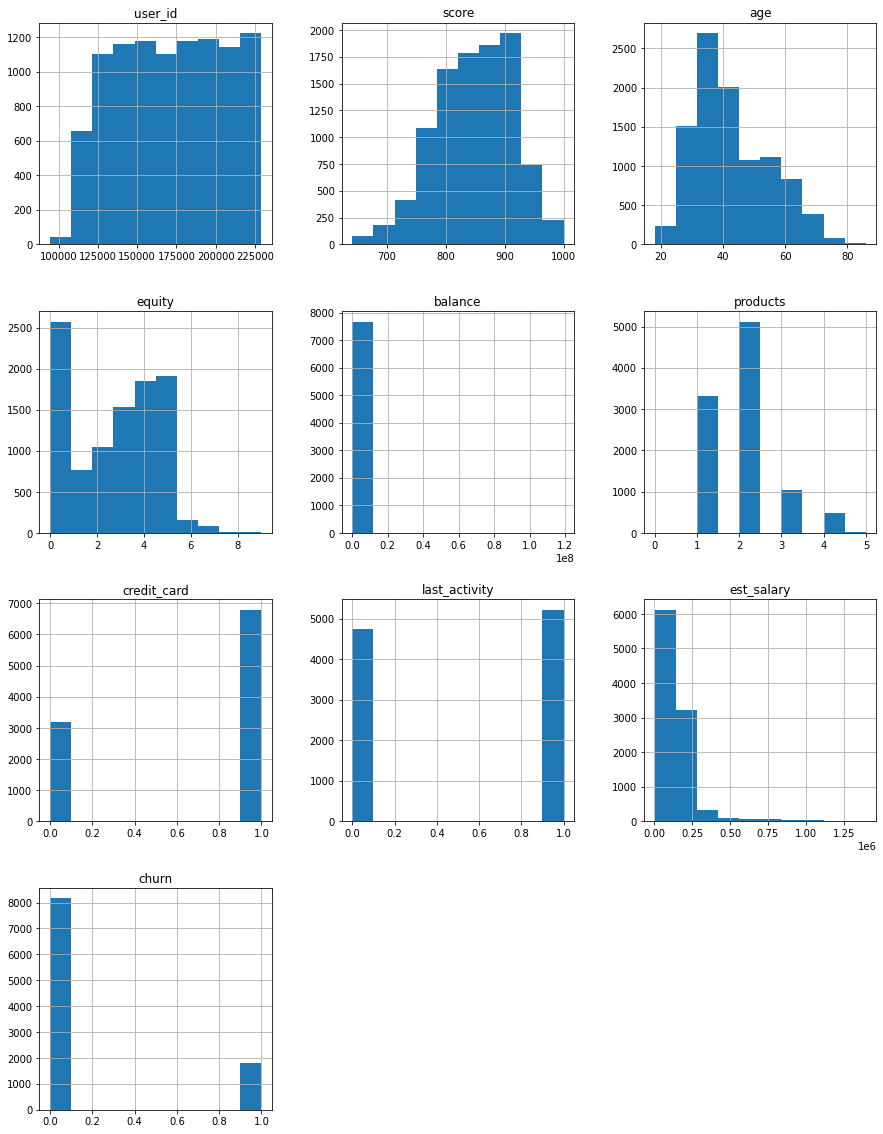

In [21]:
data.hist(figsize=(15, 20))
plt.show()


Изучив данные с помщью метода describe() и hits() можно сказать, что явные выбросы имеют столбцы **equity** и **est_salary**. На данном этапе с ними ничего делать не будем, однако будем иметь данную информацию ввиду при дальнейшем анализе.
Так же обнаружено, что в столбце **products** минимальное количетсво продуктов **0**. Что может быть аномалией. Более внимательнее изучим эти строчки датафрейма.

In [22]:
data[data['products'] == 0]

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
8957,147837,962.0,Рыбинск,Ж,79,3,NaN,0,0,0,25063.96,1


<!-- апа -->

Видимо, произошла ошибка системы. В банке не может быть клиентов, которые не пользуются ни одним из продуктов. Должен быть открыт как минимум расчетный счет.
Поэтому принимем решение удалить данного клиента из выгрузки.

In [23]:
data = data[data['products'] != 0]

Данные исследованы, анномали обработаны. 
Приступаем к составлению характеристик отточности.

### Составить гистограмму отточности клиентов под кажому парамерту (возраст, пол, кол-во продуктов и т.д.)

In [24]:
data.columns

Index(['user_id', 'score', 'city', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary', 'churn'],
      dtype='object')

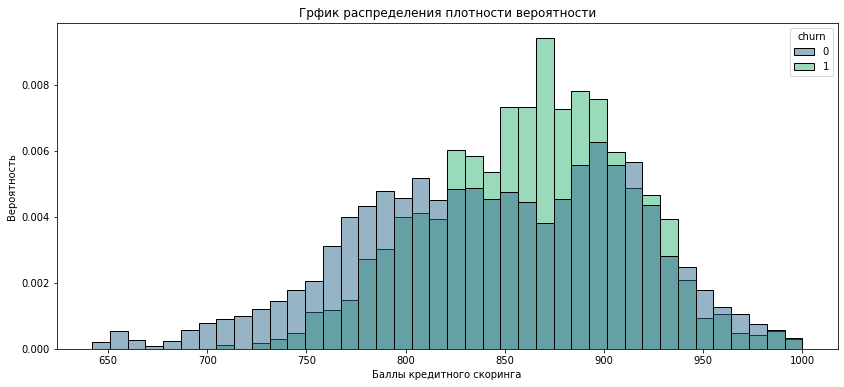

In [25]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='score',
    stat='density',
    common_norm=False,
    palette='viridis'
)

plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Баллы кредитного скоринга')
plt.ylabel('Вероятность')
plt.show()

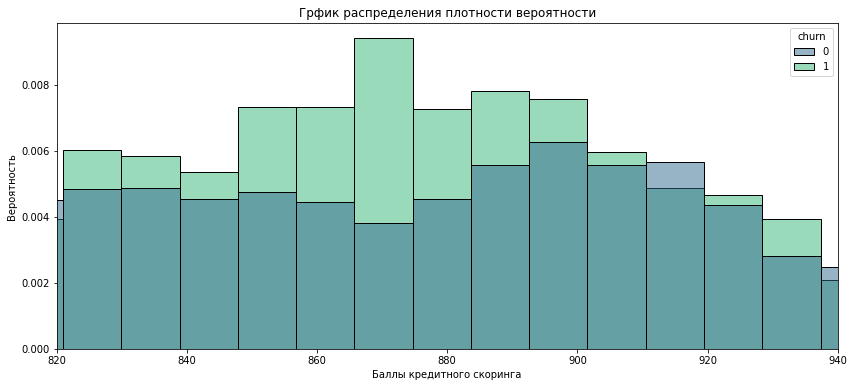

In [26]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='score',
    stat='density',
    common_norm=False,
    palette='viridis',
    
)

plt.xlim(820, 940)
plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Баллы кредитного скоринга')
plt.ylabel('Вероятность')
plt.show()

Баллы кредитного скоринга у клиентов банка от 650 до 1000.
Основная масса клиентов имеет от 750 до 950 баллов кредитного скоринга.
Клиенты имеющие скоринг баллы от **820** до **930** баллов склонны покинуть банк.
Клиенты с низскими баллами кредитного скоринга от 650 до 850 и с большими баллами кредитного скоринга не сколны уходить из банка.

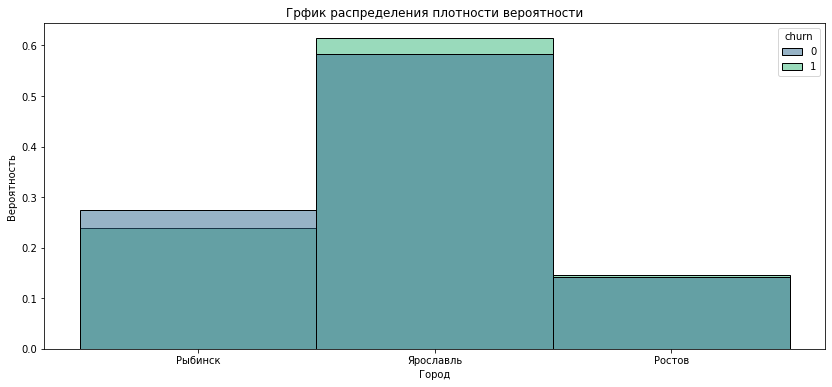

In [27]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='city',
    stat='density',
    common_norm=False,
    discrete=True,
    palette='viridis'
)

plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Город')
plt.ylabel('Вероятность')
plt.show()

Банк представлен в трех городах : Рыбинск, Ярославль, Ростов.
Основная масса клиентов находится в Ярославле Там же наблюдается и самый высокий уровень отточности клиентов.
На втором месте по количеству клиентов находится город Рыбинск, в нем преобладает доля клиентов клиентов, кто остается в банке.
И на третьем месте город Ростов. Уровень там так же не значительный, но выше, чем в Рыбинске.

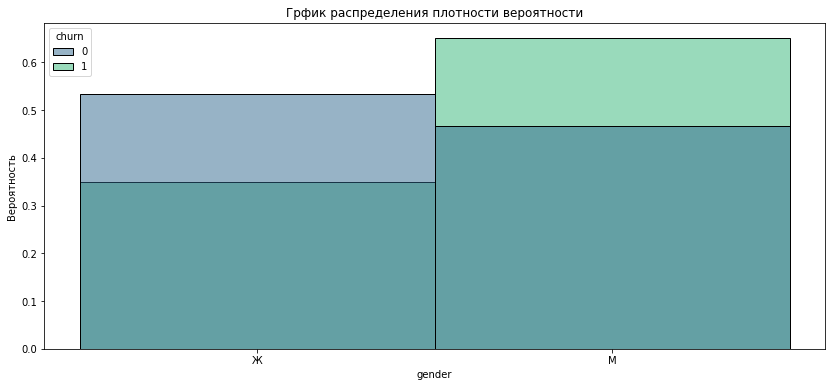

In [28]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='gender',
    stat='density',
    common_norm=False,
    discrete=True,
    palette='viridis'
)

plt.title('Грфик распределения плотности вероятности')
plt.xlabel('gender')
plt.ylabel('Вероятность')
plt.show()

В банке преобладает доля мужчин, при этом они так же более склонны к оттоку.

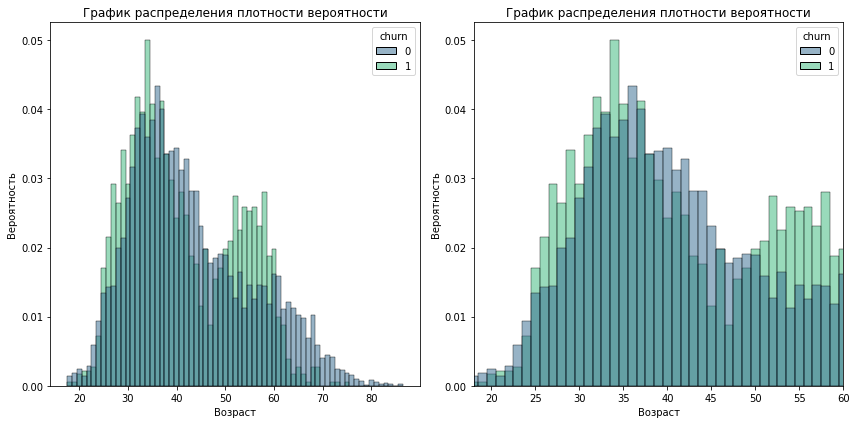

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='age',
    stat='density',
    common_norm=False,
    discrete=True,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('График распределения плотности вероятности')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Вероятность')

sns.histplot(
    data=data,
    hue='churn',
    x='age',
    stat='density',
    common_norm=False,
    discrete=True,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlim(18, 60)
axes[1].set_title('График распределения плотности вероятности')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Вероятность')

plt.tight_layout()
plt.show()

В основном клиенты банка в возрасте от 25 до 70 лет.
Возраст клиентов с высоким уровнем отточности от 25 до 35 и от 50 до 60 лет.

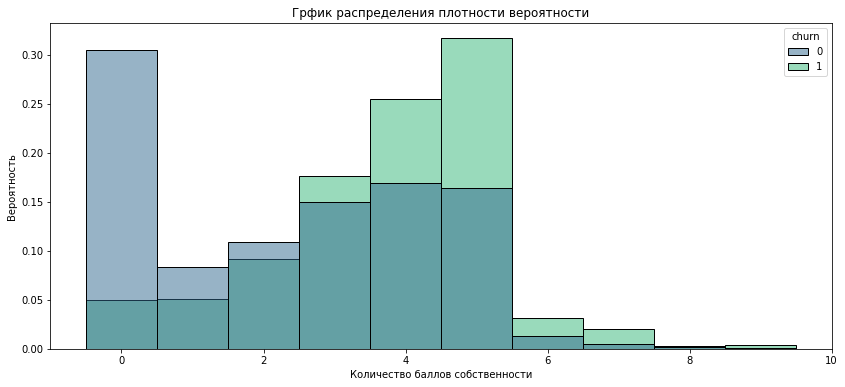

In [30]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='equity',
    stat='density',
    common_norm=False,
    discrete=True,
    palette='viridis'
)

plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Количество баллов собственности')
plt.ylabel('Вероятность')
plt.show()

Клиенты бака либо не имею собственности, либо имеют среднее значение собственности по шкале банка.
В зону риска отточнисти клиентов входят все клиенты, кто имеет более трех баллов по шкале банка.

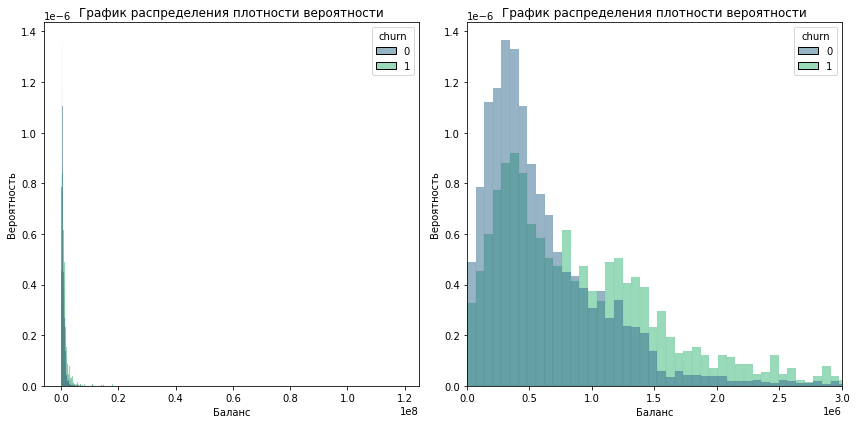

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


sns.histplot(
    data=data,
    hue='churn',
    x='balance',
    stat='density',
    common_norm=False,
    palette='viridis',
    
    ax=axes[0]
)
axes[0].set_title('График распределения плотности вероятности')
axes[0].set_xlabel('Баланс')
axes[0].set_ylabel('Вероятность')


sns.histplot(
    data=data,
    hue='churn',
    x='balance',
    stat='density',
    common_norm=False,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlim(0,  3000000)
axes[1].set_title('График распределения плотности вероятности')
axes[1].set_xlabel('Баланс')
axes[1].set_ylabel('Вероятность')

plt.tight_layout()
plt.show()

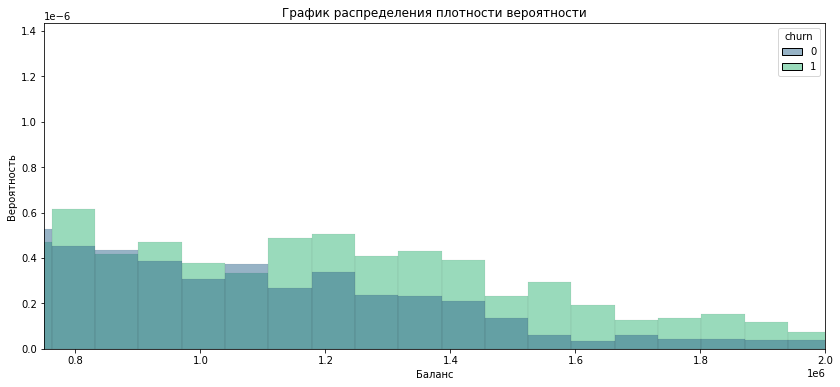

In [32]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='balance',
    stat='density',
    common_norm=False,
    palette='viridis'
)

plt.xlim(750000, 2000000)
plt.title('График распределения плотности вероятности')
plt.xlabel('Баланс')
plt.ylabel('Вероятность')
plt.show()

В осноном клиенты имеют на счетах до 500 000 руб и они не сколоны к оттоку.

На графике видно, что доля отточности повышается с увеличением суммы баланса клиента.

Мы видим первый всплеск отточности у клиентов с балансом примерно 800 000 руб. 

Второй всплекст отточности у клиентов с балансом около 1 000 000.

И после примерно 1 100 000 наблюдается устойчивый тренд к оттоку клиентов.

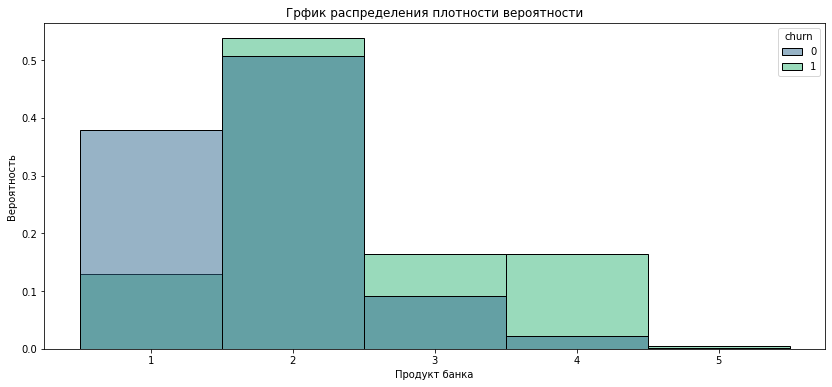

In [33]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='products',
    stat='density',
    discrete=True,
    common_norm=False,
    palette='viridis'
)

plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Продукт банка')
plt.ylabel('Вероятность')
plt.show()

Основная масса клиентов имеет 1 или 2 продукта.
Причем клиенты имеющие 1 продукт не склонны к оттоку. 
Клиенты имеющие от 2 продуктов банка имеют выскорую долю оттока.

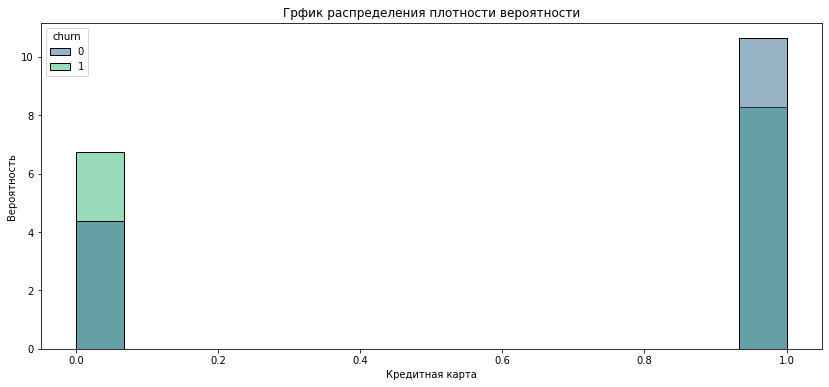

In [34]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='credit_card',
    stat='density',
    common_norm=False,
    palette='viridis'
)

plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Кредитная карта')
plt.ylabel('Вероятность')
plt.show()

Клиентов, у которых есть клиентидная карта больше, чем тех, у кого её нет.
У клиентов, у которых есть кредитная картна не склонны к оттоку. А те, у кого нет кредитной карты более склонны к оттоку.

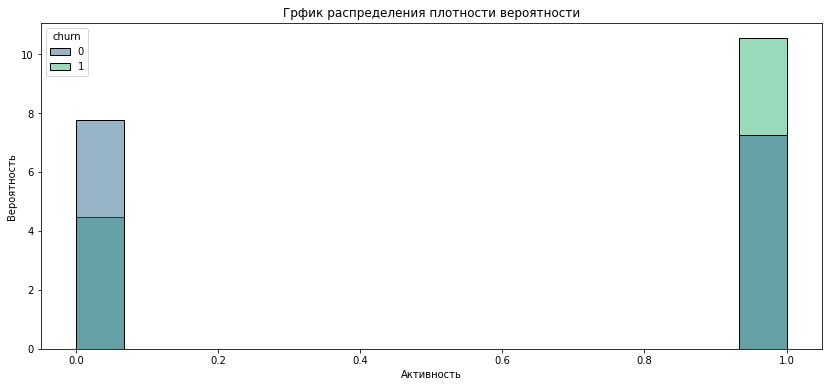

In [35]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='last_activity',
    stat='density',
    common_norm=False,
    palette='viridis'
)

plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Активность')
plt.ylabel('Вероятность')
plt.show()

Активные клиенты банка более склонны к оттоку.

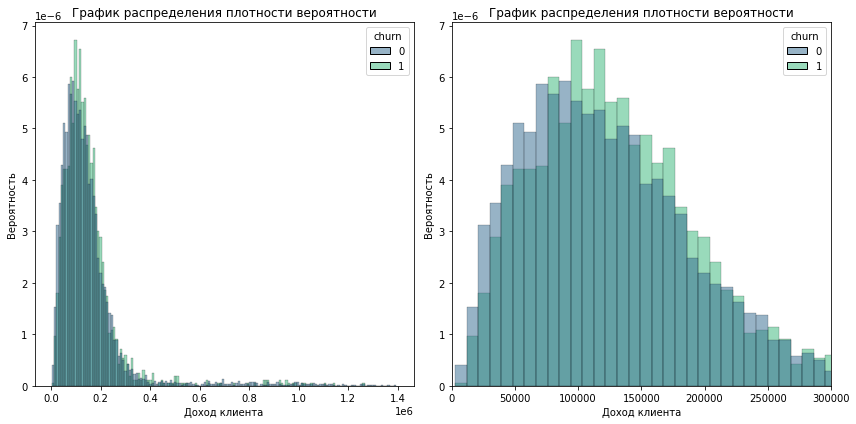

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Первый график
sns.histplot(
    data=data,
    hue='churn',
    x='est_salary',
    stat='density',
    common_norm=False,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('График распределения плотности вероятности')
axes[0].set_xlabel('Доход клиента')
axes[0].set_ylabel('Вероятность')

# Второй график с ограничением по оси X
sns.histplot(
    data=data,
    hue='churn',
    x='est_salary',
    stat='density',
    common_norm=False,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlim(0, 300000)
axes[1].set_title('График распределения плотности вероятности')
axes[1].set_xlabel('Доход клиента')
axes[1].set_ylabel('Вероятность')

plt.tight_layout()
plt.show()

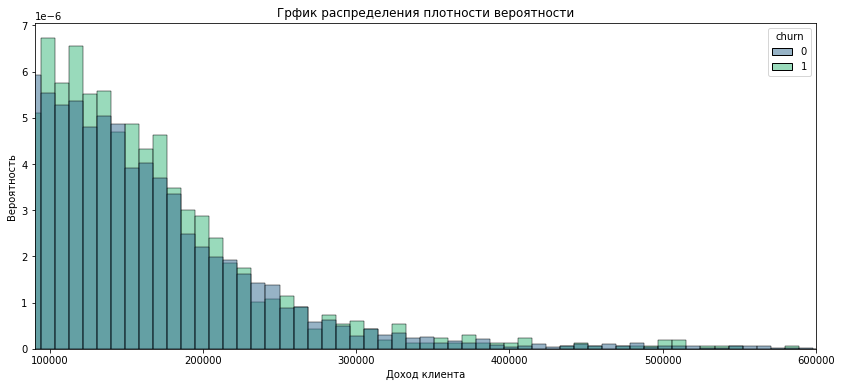

In [37]:
plt.figure(figsize=(14, 6))

sns.histplot(
    data=data,
    hue='churn',
    x='est_salary',
    stat='density',
    common_norm=False,
    palette='viridis'
)


plt.xlim(90000, 600000)
plt.title('Грфик распределения плотности вероятности')
plt.xlabel('Доход клиента')
plt.ylabel('Вероятность')
plt.show()

Доход клиентов банка варьируется от 20 000 до 300 000 руб.
При более детальном рассмотрении хвоста графика мы видим, что отточности подвержены клиенты с доходом от 100 000 руб. до 210 000 руб. 
Так же есть клиенты с доходом примерно от 280 000 до 300 000 руб. склоннные к оттоку, с доходом 390 000 - 410 000 и клиеннты с доходои 490 000 до 510 000 руб. Однако их количество крайне мало.

In [38]:
data.columns

Index(['user_id', 'score', 'city', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary', 'churn'],
      dtype='object')

**Вывод**

Изучив гистрограммы распредений по каждому признаку отточности можно выявить следующие закономерности.

Наибольшая вероятность ухода из банка у клиентов со следующими характеристиками:

- **score** - от 820 до 930,
- **city** - Ярославль,
- **gender** - мужчины,
- **age** - от 25 до 35 и от 50 до 60 лет,
- **equity** - 3 балла и более,
- **balance** - от 1 100 000 руб.,
- **products** - от 2 продуктов банка,
- **credit_card** - не имеющие кредитных карт,
- **last_activity** - активные,
- **est_salary** - от 100 000  до 210 000.

### Составить график зависимости (корреляции) отточности по каждому параметру.

In [39]:

phik_matrix = data[data.columns.difference(['user_id'])].phik_matrix()
phik_matrix

interval columns not set, guessing: ['age', 'balance', 'churn', 'credit_card', 'equity', 'est_salary', 'last_activity', 'products', 'score']


,age,balance,churn,city,credit_card,equity,est_salary,gender,last_activity,products,score
age,1.000000,0.019169,0.192511,0.091464,0.157172,0.045939,0.359702,0.286169,0.090472,0.140869,0.033898
balance,0.019169,1.000000,0.024672,0.039931,0.000000,0.000000,0.374367,0.045434,0.000000,0.000000,0.170884
churn,0.192511,0.024672,1.000000,0.016674,0.201963,0.352114,0.048961,0.220117,0.262573,0.259842,0.229553
city,0.091464,0.039931,0.016674,1.000000,0.074611,0.062574,0.170837,0.011849,0.030504,0.125263,0.090855
credit_card,0.157172,0.000000,0.201963,0.074611,1.000000,0.221400,0.038332,0.195636,0.049567,0.271043,0.208165
equity,0.045939,0.000000,0.352114,0.062574,0.221400,1.000000,0.285537,0.063504,0.051124,0.583305,0.527444
est_salary,0.359702,0.374367,0.048961,0.170837,0.038332,0.285537,1.000000,0.144090,0.044890,0.222246,0.395130
gender,0.286169,0.045434,0.220117,0.011849,0.195636,0.063504,0.144090,1.000000,0.012997,0.071728,0.070593
last_activity,0.090472,0.000000,0.262573,0.030504,0.049567,0.051124,0.044890,0.012997,1.000000,0.112814,0.051635
products,0.140869,0.000000,0.259842,0.125263,0.271043,0.583305,0.222246,0.071728,0.112814,1.000000,0.419642


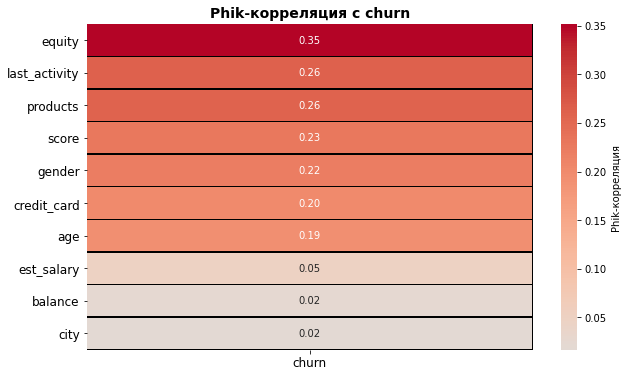

In [40]:

plt.figure(figsize=(10, 6))
sns.heatmap(
    phik_matrix[["churn"]].drop("churn").sort_values(by="churn", ascending=False),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="black", cbar_kws={'label': 'Phik-корреляция'}
)
plt.title("Phik-корреляция с churn", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.show()


- **Наибольшая связь с churn:**

 equity (0.35) — самая сильная корреляция.
 last_activity (0.26) и products (0.26) также имеют значимое влияние.
- **Средняя корреляция:**

score (0.23), gender (0.22), credit_card (0.20), age (0.19) — возможное влияние на отток клиентов.
- **Слабая связь с churn:**

est_salary (0.05), balance (0.02), city (0.02) почти не влияют на отток.

### Составить портрет клиентов, которые обслуживаются в банке и которые ушли. 

Портрет клиента, которые не склонен уходить из банка:

- **score** - от 650 до 850 и от 900 до 100
- **city** - Рыбинск,Ростов,
- **gender** - женщины,
- **age** - от 18 до 24 и от 36 до 49 лет и от 60 до 86, 
- **equity** - от 0 до 2 баллов,
- **balance** - до 1 000 000 руб.,
- **products** - от 0 до 2 продуктов банка,
- **credit_card** - имеющие кредитных карт,
- **last_activity** - неактивные,
- **est_salary** - до 100 000 и выше.    

Наибольшая вероятность ухода из банка у клиентов со следующими характеристиками:

- **score** - от 850 до 900,
- **city** - Ярославль,
- **gender** - мужчины,
- **age** - от 25 до 35 и от 50 до 60 лет,
- **equity** - 3 балла и более,
- **balance** - от 1 000 000 руб.,
- **products** - от 3 продуктов банка,
- **credit_card** - не имеющие кредитных карт,
- **last_activity** - активные,
- **est_salary** - от 100 000 и выше.

## Проверка статистических гипотез.

### Гипотеза различия доходов между клиентами которые ушли и которые остались.

Нулевая гипотеза (H0): Средний доход клиентов, которые ушли **не отличается** от среднего дохода клиентов, которые остались в банке.

Альтернативная гипотеза (H1): Средний доход клиентов, которые ушли **выше** среднего дохода клиентов, которые остались в банке.

Гипотеза о равенстве средних двух генеральных совокупностей.

In [41]:
alpha = 0.05

results = st.ttest_ind( data[data['churn'] == 1]['est_salary'],  data[data['churn'] == 0]['est_salary'], alternative='greater')

print(f'p-value: {results.pvalue}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу.')

p-value: 0.42504411936290176
Нет оснований отвергнуть нулевую гипотезу.


Исходя из результатов статестического теста можно сказать, что средний доход клиентов, которые ушли из банка не отличается от среднего дохода клиентов, которые остались.

### Сформировать и проверить вторую гипотезу. 

Нулевая гипотеза (H0): Среднее количество продуктов банка у клиентов, которые ушли **не отличается** от среднего количества продуктов у  клиентов, которые остались в банке.

Альтернативная гипотеза (H1): Среднее количество продуктов банка у клиентов, которые ушли **выше** чем, среднее количество продуктов у  клиентов, которые остались в банке.

Гипотеза о равенстве средних двух генеральных совокупностей.

In [42]:
data.head()

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
0,183012,850.0,Рыбинск,Ж,25,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34,5,174.00,1,1,0,67353.16,1


In [43]:
alpha = 0.05

results = st.ttest_ind( data[data['churn'] == 1]['products'],  data[data['churn'] == 0]['products'], alternative='greater')

print(f'p-value: {results.pvalue}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу.')

p-value: 1.2589373271223973e-208
Отвергаем нулевую гипотезу.


Исходя из результатов статистического теста можно сказать, что среднее количетсво продуктов банка у клиентов, которые ушли из банка выше, чем среднее количетсво продуктов банка у клиентов, которые остались.

## Промежуточный итог.


**В ходе исследования были выполнены следующие этапы:**

- Проведена первичная предобработка данных: исправлены названия столбцов, обработаны пропуски, скорректированы типы данных.
- Проведен исследовательский анализ данных: изучены аномалии и выбросы, построены распределения по ключевым характеристикам клиентов.
- Выявлены факторы, влияющие на отток клиентов:
  - Высокий балл кредитного скоринга.
  - Наличие значительных остатков на счетах.
  - Активность клиента.
  - Пол, возраст и другие параметры.
- Проверены статистические гипотезы:
  - Различие доходов между клиентами, покинувшими банк, и оставшимися оказалось незначительным.
  - Однако клиенты, покинувшие банк, в среднем пользовались большим количеством продуктов.
- Выделены основные группы клиентов с высокой вероятностью оттока.

Эти выводы позволят перейти к следующему этапу – сегментации клиентов и формированию стратегии удержания.

## Сегментация клиентов

### Формирование сегментов на основании признаков отточности клиентов из п.3.2 (2-3 признака для формирования сегмента, количество клиентов попадающих в сегмент от 500 до 2000 чекловек и отточность клиентов от 30%)

- **score** - от 820 до 930,
- **city** - Ярославль,
- **gender** - мужчины,
- **age** - от 25 до 35 и от 50 до 60 лет,
- **equity** - 3 балла и более,
- **balance** - от 1 100 000 руб.,
- **products** - от 2 продуктов банка,
- **credit_card** - не имеющие кредитных карт,
- **last_activity** - активные,
- **est_salary** - от 100 000  до 210 000 руб.

Т.к. в основном клиентами с высоким риском оттока являются мужчины, проживающие в областном центре, в возрасте от 25 до 35 и от 50 и до 60 лет, имеющие имущество (автомобиль, квартира), которые актино пользуются продуктами банка, имеют доход от 100 000 до 210 000 руб. и также имеют средства на балансе от 1 100 000 руб. и не пользуются кредитными продуктами банка мы будем смотреть сегментацию по ним.

**Клиенты мужского пола в возрасте от 25 до 35 лет и в возрасте от 50 до 60 лет, имеющие имущество.**

In [44]:
segment_1 =  data.query('(25<=age<= 35 or 50<=age<=60) and (gender == "М") and (equity >= 3)')

In [45]:
print(f"Доля оттока клиентов: {segment_1['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_1['user_id'].count()}")

Доля оттока клиентов: 42%
Количество клиентов в сегменте: 1438


**Активные клиенты в возрасте от 25 до 35 лет и в возрасте от 50 до 60 лет, проживающие в Ярославле.**

In [46]:
segment_2 =  data.query('(25<=age<= 35 or 50<=age<=60) and (city == "Ярославль") and (last_activity == 1)')

In [47]:
print(f"Доля оттока клиентов: {segment_2['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_2['user_id'].count()}")

Доля оттока клиентов: 35%
Количество клиентов в сегменте: 1472


**Активные клиенты в возрасте от 25 до 35 лет и в возрасте от 50 до 60 лет, с доходом от 100 000 до 210 000 руб.**

In [48]:
segment_3 = data.query('(25<=age<= 35 or 50<=age<=60) and (100000 <= est_salary <= 210000) and (last_activity == 1)')

In [49]:
print(f"Доля оттока клиентов: {segment_3['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_3['user_id'].count()}")

Доля оттока клиентов: 39%
Количество клиентов в сегменте: 1057


**Клиенты в возрасте от 25 до 35 лет и в возрасте от 50 до 60 лет, с высокими скоринг баллами, без кредитных карт**

In [50]:
segment_4 =  data.query('(25<=age<= 35 or 50<=age<=60) and (820<=score<=930) and (credit_card == 0)')

In [51]:
print(f"Доля оттока клиентов: {segment_4['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_4['user_id'].count()}")

Доля оттока клиентов: 44%
Количество клиентов в сегменте: 1002


**Активные клиенты в возрасте от 25 до 35 и от 50 до 60 лет с 2 и более продуктами.**

In [52]:
segment_5 =  data.query('(last_activity == 1) and (products>=2) and (25<=age<= 35 or 50<=age<=60)')

In [53]:
print(f"Доля оттока клиентов: {segment_5['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_5['user_id'].count()}")

Доля оттока клиентов: 42%
Количество клиентов в сегменте: 1745


**Клиенты без кредитных карт, имеющие выскокий кредитный скоринг и имеющие доход от 100 000 до 210 000 руб.**

In [54]:
segment_6 =  data.query('(credit_card == 0 ) and (820<=score<=930) and (100000 <= est_salary <= 210000)')

In [55]:
print(f"Доля оттока клиентов: {segment_6['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_6['user_id'].count()}")

Доля оттока клиентов: 37%
Количество клиентов в сегменте: 996


**Клиенты из города Ярославль, имеющие на балансе более 1 100 000 руб.**

In [56]:
segment_7 =  data.query('(city == "Ярославль") and (balance >= 1100000)')

In [57]:
print(f"Доля оттока клиентов: {segment_7['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_7['user_id'].count()}")

Доля оттока клиентов: 44%
Количество клиентов в сегменте: 999


**Клиенты из Ярославля с имущественными баллами от 3 и более, мужского пола.**

In [58]:
segment_8 =  data.query('(city == "Ярославль") and (equity >= 3) and (gender == "М")')

In [59]:
print(f"Доля оттока клиентов: {segment_8['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_8['user_id'].count()}")

Доля оттока клиентов: 37%
Количество клиентов в сегменте: 1597


**Клиенты с доходом от 100 000 до 210 000 руб., пользующиеся 2 и более продуктами банка, но не кредитной картой.**

In [60]:
segment_9 =  data.query('(products >= 2) and (100000 <= est_salary <= 210000) and (credit_card == 0)')

In [61]:
print(f"Доля оттока клиентов: {segment_9['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_9['user_id'].count()}")

Доля оттока клиентов: 34%
Количество клиентов в сегменте: 1243


**Клиенты мужского пола с доходом от 100 000 до 210 000 руб. и высокими скорринг баллами.**

In [62]:
segment_10 =  data.query('(820<=score<=930) and (100000 <= est_salary <= 210000) and (gender == "М")')

In [63]:
print(f"Доля оттока клиентов: {segment_10['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_10['user_id'].count()}")

Доля оттока клиентов: 31%
Количество клиентов в сегменте: 1398


### Сформировать топ сегментов по отточности.

In [64]:
segment_4
print(f"Доля оттока клиентов: {segment_4['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_4['user_id'].count()}")


Доля оттока клиентов: 44%
Количество клиентов в сегменте: 1002


**Описание:**  

- Клиенты в возрасте от 25 до 35 лет и в возрасте от 50 до 60 лет, с высокими скоринг баллами, без кредитных карт.

**Рекомендации:**  

- Проанализировать рынок кредитных карт и иных кредитных продуктов в регионе и предложить клиентам с выскоким скоринг баллами более выгодные предложения. (Например, первые 3 мес. пониженный %, оплата без просрочек в течение 6 мес. уменьшает процентную ставку на оставшийся срок)
- Повысить для клиента ценность кредитной карты банка:
    - кобрендинг
    - повышенный кешбек кредитных карт
    - более мягкий льготный период
    - дополнительные бонусы для других продуктов при испльзовании кредитных карт
- Повысить скорость и удобство доступа клиентов к продуктам банка (мобильное приложение, скорость принятия решения, доставка кредитных карт и иное)


In [65]:
segment_7
print(f"Доля оттока клиентов: {segment_7['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_7['user_id'].count()}")

Доля оттока клиентов: 44%
Количество клиентов в сегменте: 999


**Описание:**

- Клиенты из города Ярославль, имеющие на балансе более 1 100 000 руб.

**Рекомендации:**

- Предложить клиентам конкурентные инстументы приумножения сбережений:
    - вклады с повышенной ставкой
    - накопительное или инвестиционное страхование жизни
- Подготовить специальные условия по кредитованию для клиентов, кто хранит на счетах банка сумму более 1 000 000 руб.
- Предложить иные бонусы и привилегии для клиентов высоким балансом.
- Сделать доступ к продуктам банка более быстрым и удобным (снятие наличных в любых банкоматов, мобильное приложение, дистанционное оформление продуктов)

In [66]:
segment_5
print(f"Доля оттока клиентов: {segment_5['churn'].mean()*100:.0f}%")
print(f"Количество клиентов в сегменте: {segment_5['user_id'].count()}")

Доля оттока клиентов: 42%
Количество клиентов в сегменте: 1745


**Описание:**

- Активные клиенты в возрасте от 25 до 35 и от 50 до 60 лет с 2 и более продуктами.

**Рекомендации:**

- Проанализировать наиболее популярные продукты банка и сравнить с предложениями конкурентов. При необходимости сделать продукт банка более ценным для клиента.
- Проводить маркетинговые меропрятия по удержанию активных клиентов путем вознаграждений (повышенный кешбек, акции, скидки у партнеров и иные мероприятия направленые на увеличение лояльности действующих клиентов.)
- Проанализировать какие продуктами пользуюся клиенты, у которых более 2х продуктов банка. (Например, если это разные кредиты - предложить объеденить их в один с немного пониженной ставой. Если это влклады или инвестиционные продукты предложить открыть еще один на улучшенных условиях.)


## Вывод

**В рамках анализа оттока клиентов из банка была проведена комплексная работа:**

- Обработка данных
    - Подготовлены и очищены данные.
    - Устранены аномалии и пропущенные значения.
    
- Исследовательский анализ
    - Определены ключевые характеристики клиентов, склонных к уходу.
    - Построены визуализации распределений и зависимости факторов от оттока.

- Статистический анализ
    - Проверены гипотезы о влиянии различных факторов на уход клиентов.
    
- Сегментация клиентов
    - Выделены сегменты клиентов с высоким риском оттока.
    - Разработаны рекомендации для снижения оттока.

## Материалы
* [Презентация](https://disk.yandex.ru/i/kyzRJBZWEhrd7g)